In [1]:
from typing import List, Dict, Any

from natasha import (
    Segmenter, MorphVocab,
    NewsEmbedding, NewsMorphTagger, NewsSyntaxParser, NewsNERTagger,
    Doc
)
from datasets import load_dataset

from yargy import Parser, rule, or_
from yargy.pipelines import morph_pipeline, caseless_pipeline
from yargy.predicates import gram
from yargy.interpretation import fact
from yargy.tokenizer import MorphTokenizer

from src.parser import process_dataset
from src.utils import load_natasha_data, get_stats
from src.yargy_utils import extract_entities_yargy
from src.eval import evaluate, get_error_pairs
from src.plots import make_simle_stats, plot_ner_word_statistics

import warnings
warnings.filterwarnings("ignore")

In [2]:
dataset = load_dataset("gusevski/factrueval2016", cache_dir='data')
dataset

Repo card metadata block was not found. Setting CardData to empty.


DatasetDict({
    train: Dataset({
        features: ['data'],
        num_rows: 1
    })
    validation: Dataset({
        features: ['data'],
        num_rows: 1
    })
    test: Dataset({
        features: ['data'],
        num_rows: 1
    })
})

<Figure size 1600x800 with 0 Axes>

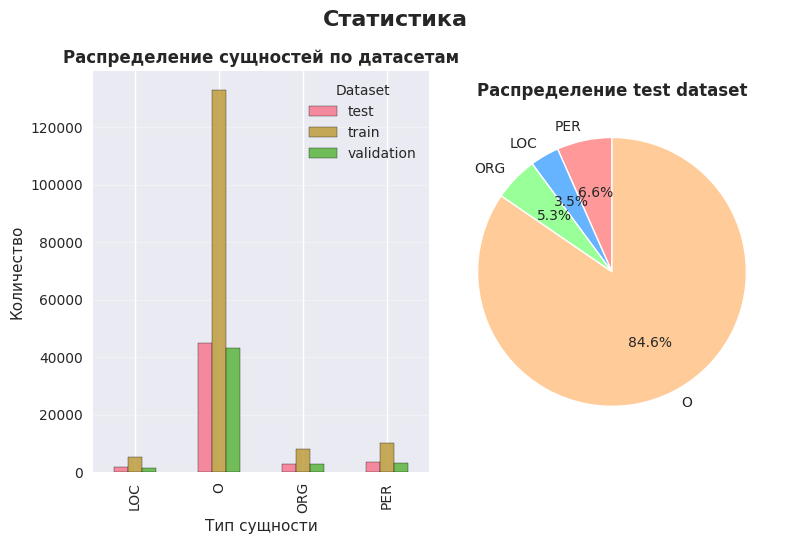

In [3]:
make_simle_stats(get_stats(dataset)) # type: ignore

In [4]:
entity_counts, natasha_data = process_dataset("gusevski/factrueval2016")

Repo card metadata block was not found. Setting CardData to empty.


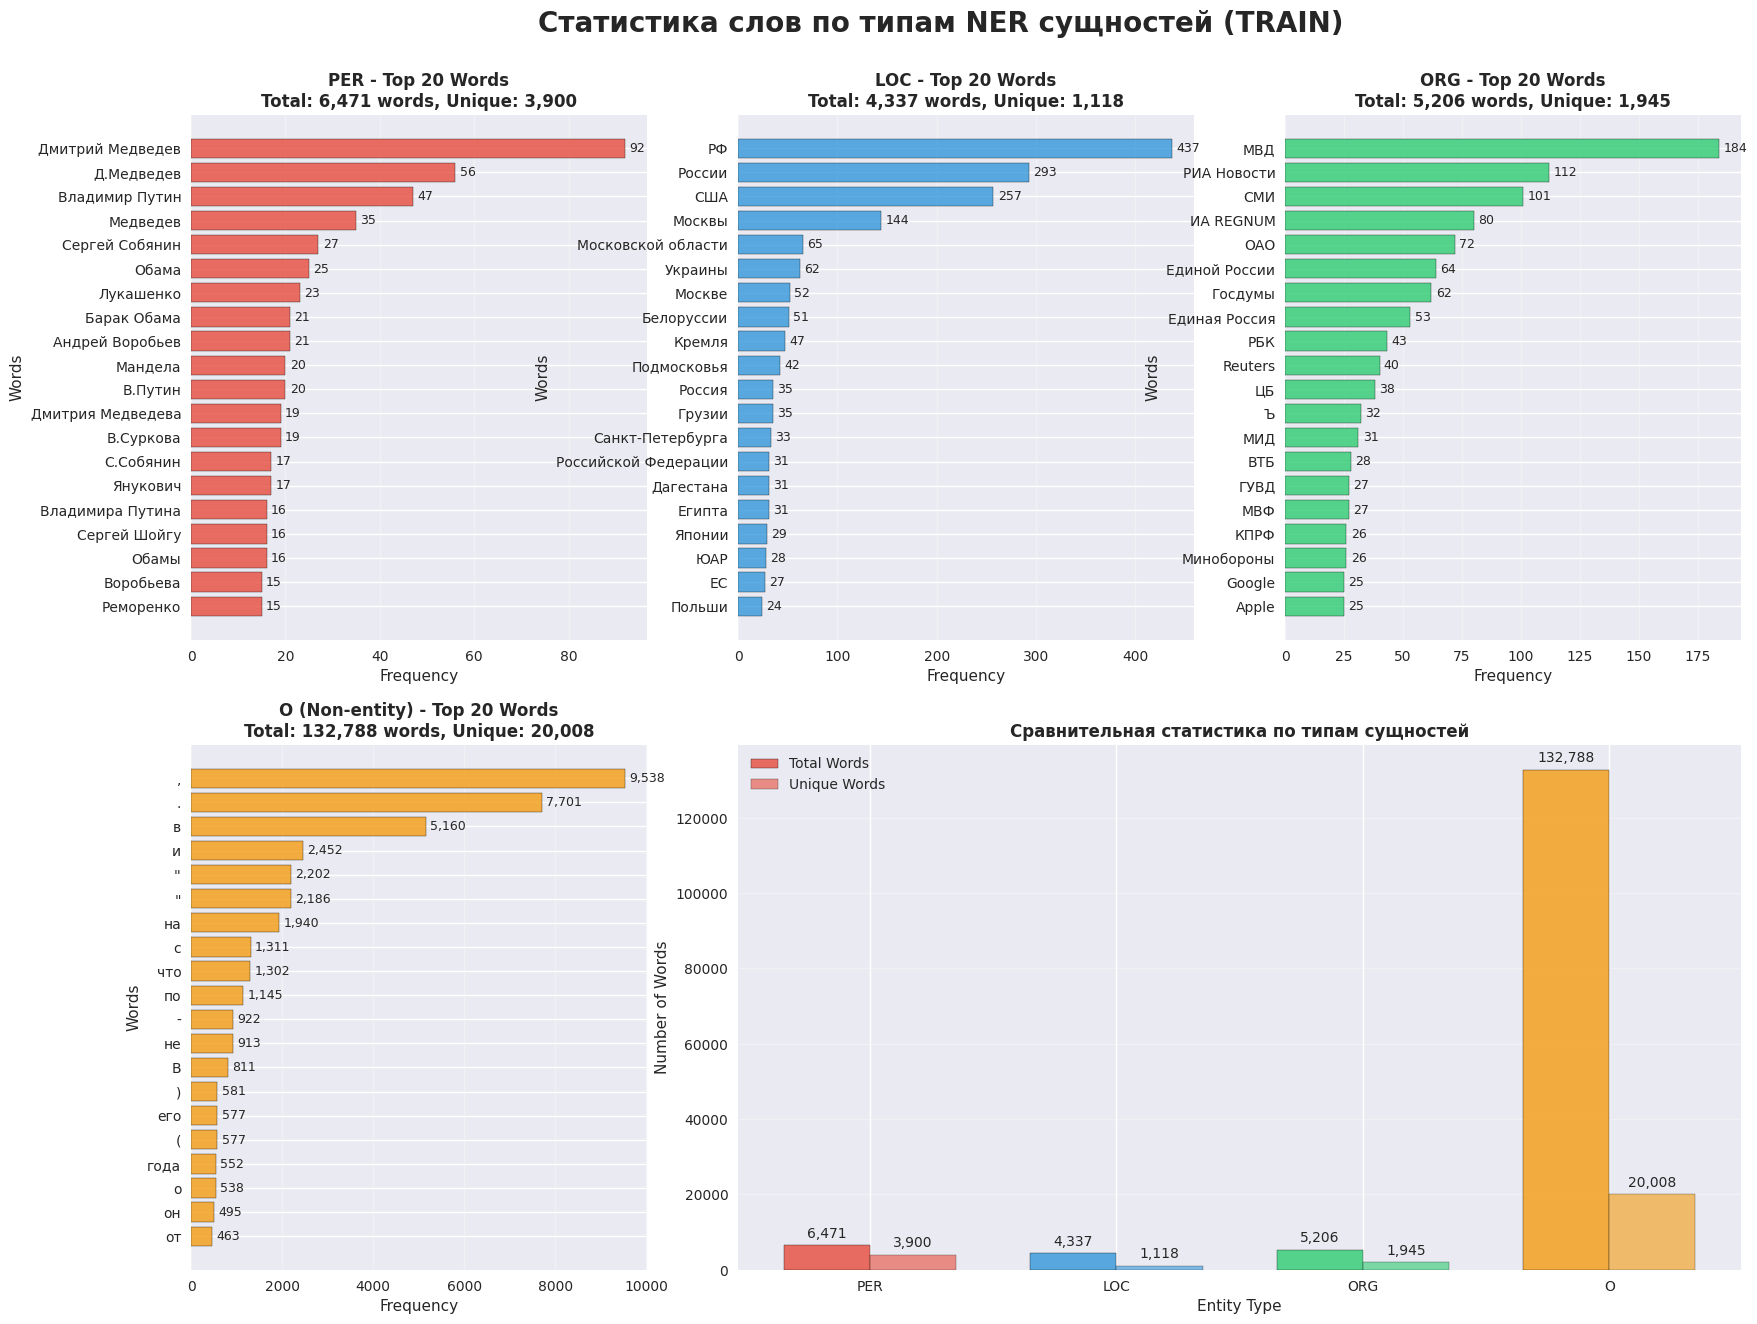

ДЕТАЛЬНАЯ СТАТИСТИКА СЛОВ ПО ТИПАМ NER СУЩНОСТЕЙ

PER:
  Всего слов: 6,471
  Уникальных слов: 3,900
  Коэффициент уникальности: 0.603
  Топ-5 слов: Дмитрий Медведев, Д.Медведев, Владимир Путин, Медведев, Сергей Собянин

LOC:
  Всего слов: 4,337
  Уникальных слов: 1,118
  Коэффициент уникальности: 0.258
  Топ-5 слов: РФ, России, США, Москвы, Московской области

ORG:
  Всего слов: 5,206
  Уникальных слов: 1,945
  Коэффициент уникальности: 0.374
  Топ-5 слов: МВД, РИА Новости, СМИ, ИА REGNUM, ОАО

O:
  Всего слов: 132,788
  Уникальных слов: 20,008
  Коэффициент уникальности: 0.151
  Топ-5 слов: ,, ., в, и, ''


In [5]:
plot_ner_word_statistics(entity_counts['train'])

### YARGY + SPACY

#### Exp1. Набор самый "банальных" базовых правил

In [ ]:
tokenizer = MorphTokenizer()

Name = fact('Name', ['first', 'last'])

FIRST_NAME = gram('Name').interpretation(Name.first)
LAST_NAME = gram('Surn').interpretation(Name.last)


PER_RULE = or_(
    rule(FIRST_NAME, LAST_NAME),
    rule(LAST_NAME, FIRST_NAME)
).interpretation(Name)


COUNTRIES = ['Россия', 'РФ', 'США', 'Украина', 'Германия', 'Франция', 'Китай']
CITIES = ['Москва', 'Петербург', 'Киев', 'Нью-Йорк', 'Лондон', 'Париж']

LOC_RULE = or_(
    rule(morph_pipeline(COUNTRIES)),
    rule(morph_pipeline(CITIES)),
    rule(gram('Geox'))  # географические названия
)


ORGANIZATIONS = [
    'ЛДПР', 'Государственная дума', 'компания', 'корпорация', 
    'фонд', 'университет', 'институт', 'завод', 'банк'
]

ORG_RULE = or_(,
    rule(morph_pipeline(ORGANIZATIONS)),
    rule(gram('Orgn'))  # организации
)

per_parser = Parser(PER_RULE, tokenizer=tokenizer)
loc_parser = Parser(LOC_RULE, tokenizer=tokenizer)
org_parser = Parser(ORG_RULE, tokenizer=tokenizer)


In [7]:
def run_evaluation(
    data: List[Dict], 
    per_parser: Parser, 
    loc_parser: Parser, 
    org_parser: Parser
) -> List[Dict]:


    results = []
    
    for item in data:
        text = item['text']
        true_entities = item['entities']
        
        predicted_entities = extract_entities_yargy(text, per_parser, loc_parser, org_parser)
        
        results.append({
            'id': item['id'],
            'text': text,
            'true_entities': true_entities,
            'predicted_entities': predicted_entities
        })
    
    return results

In [8]:
natasha_data = load_natasha_data()

results = run_evaluation(
    natasha_data['test'],
    per_parser=per_parser,
    loc_parser=loc_parser,
    org_parser=org_parser
)
evaluate(results)

Общие метрики:
  Precision: 0.692
  Recall:    0.447
  F1:        0.543
  True entities: 5486
  Predicted entities: 3541
  Matches: 2452

Детализация по типам:
  PER:
    Precision: 0.954
    Recall:    0.374
    F1:        0.537
    True: 2187, Predicted: 856, Matches: 817
  LOC:
    Precision: 0.620
    Recall:    0.715
    F1:        0.664
    True: 1509, Predicted: 1741, Matches: 1079
  ORG:
    Precision: 0.589
    Recall:    0.311
    F1:        0.407
    True: 1790, Predicted: 944, Matches: 556


#### Exp2. ...

# Тим: https://chat.deepseek.com/share/1i3g2shcezzedak1un  - вот я тут попромптил идеи для правил, можешь отсюда что то скопировать к себе в промптики

#### Exp3. ... 

# Тим: Для 3 экспа я бы скормил все сущности в дипсик, чтобы он на списках сам построил правила

### NATASHA
#### Наташа взята как более продвинутый rule-based подход

In [5]:
class NatashaPipeline:
    def __init__(self):

        self.segmenter = Segmenter()
        self.morph_vocab = MorphVocab()
        
        self.emb = NewsEmbedding()
        self.morph_tagger = NewsMorphTagger(self.emb)
        self.syntax_parser = NewsSyntaxParser(self.emb) 
        self.ner_tagger = NewsNERTagger(self.emb)
    
    
    def process_text(self, text: str) -> Doc:
       
        doc = Doc(text)
        
        doc.segment(self.segmenter)
        doc.tag_morph(self.morph_tagger)
        doc.parse_syntax(self.syntax_parser) 
        doc.tag_ner(self.ner_tagger)
        
        for span in doc.spans:
            span.normalize(self.morph_vocab)
            
        return doc
    
    
    def extract_entities(self, doc: Doc) -> List[Dict[str, Any]]:
        
        entities = []
        
        for span in doc.spans:
            if span.type in ['PER', 'LOC', 'ORG']:
                entity = {
                    'text': span.text,
                    'type': span.type,
                    'start': span.start,
                    'end': span.stop,
                    'normalized': span.normal
                }
                entities.append(entity)
        
        return entities
    
    
    def inference(self, natasha_data: List) -> List:

        results = []
        
        for _, example in enumerate(natasha_data):
            
            text = example['text']
            true_entities = example['entities']            

            doc = self.process_text(text)
            predicted_entities = self.extract_entities(doc)

            results.append({
                'text': text,
                'true_entities': true_entities,
                'predicted_entities': predicted_entities,
                'id': example['id']
            })
        
        return results

In [6]:
natasha_data = load_natasha_data()

pipeline = NatashaPipeline()

Загружено 7746 примеров из train
Загружено 2582 примеров из validation
Загружено 2582 примеров из test


/home/timmiakov/repos/hse-materials/.venv/lib/python3.13/site-packages/pymorphy2/analyzer.py:114: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


### Test on one sample

In [7]:
test_example = natasha_data['validation'][0]
doc = pipeline.process_text(test_example['text'])
entities = pipeline.extract_entities(doc)

print(f"Текст: {test_example['text'][:100]}...")
print("\nИстинные сущности:")
for ent in test_example['entities']:
    print(f"  {ent['type']}: '{ent['text']}'")

print("\nНайденные Natasha сущности:")
for ent in entities:
    print(f"  {ent['type']}: '{ent['text']}' (нормализовано: '{ent['normalized']}')")

Текст: как акционерный коммерческий Московский муниципальный банк - Банк Москвы ,контрольный пакет акций ко...

Истинные сущности:
  ORG: 'Московский муниципальный банк - Банк Москвы'
  LOC: 'Москвы'

Найденные Natasha сущности:
  ORG: 'Московский муниципальный банк' (нормализовано: 'Московский муниципальный банк')
  ORG: 'Банк Москвы' (нормализовано: 'Банк Москвы')
  LOC: 'Москвы' (нормализовано: 'Москва')


### EXP1: Baseline Natasha

In [8]:
results = pipeline.inference(natasha_data['test'])

In [9]:
evaluate(results)

Общие метрики:
  Precision: 0.919
  Recall:    0.874
  F1:        0.896
  True entities: 5486
  Predicted entities: 5217
  Matches: 4795

Детализация по типам:
  PER:
    Precision: 0.958
    Recall:    0.900
    F1:        0.928
    True: 2187, Predicted: 2056, Matches: 1969
  LOC:
    Precision: 0.958
    Recall:    0.976
    F1:        0.967
    True: 1509, Predicted: 1538, Matches: 1473
  ORG:
    Precision: 0.834
    Recall:    0.756
    F1:        0.793
    True: 1790, Predicted: 1623, Matches: 1353


In [20]:
error_pairs = get_error_pairs(results)

In [25]:
false_postitive_pairs = [(e['false_negatives'], e['predicted_entities']) for e in error_pairs if e['false_negatives']]
false_postitive_pairs

[([{'text': 'Боксер', 'type': 'PER', 'start': 0, 'end': 6},
   {'text': 'Карли Фиорину', 'type': 'PER', 'start': 16, 'end': 29},
   {'text': 'Carly', 'type': 'PER', 'start': 31, 'end': 36}],
  [{'text': 'Карли Фиорину( Carly Fiorina )',
    'type': 'PER',
    'start': 16,
    'end': 46,
    'normalized': 'Карли Фиорину( Carly Fiorina )'},
   {'text': 'Hewlett-Packard',
    'type': 'ORG',
    'start': 88,
    'end': 103,
    'normalized': 'Hewlett-Packard'}]),
 ([{'text': 'К-Агро', 'type': 'ORG', 'start': 58, 'end': 64},
   {'text': 'ОАО', 'type': 'ORG', 'start': 91, 'end': 94},
   {'text': 'ОАО', 'type': 'ORG', 'start': 203, 'end': 206},
   {'text': 'Корпорация развития Калужской',
    'type': 'ORG',
    'start': 210,
    'end': 239},
   {'text': 'К-Агро', 'type': 'ORG', 'start': 403, 'end': 409}],
  [{'text': 'Калужской области',
    'type': 'LOC',
    'start': 2,
    'end': 19,
    'normalized': 'Калужская область'},
   {'text': "ОАО `` Россельхозбанк '' I-ORG",
    'type': 'ORG',
  